<a href="https://colab.research.google.com/github/RMoulla/Python_AFD/blob/main/TP_Analyses_Donn%C3%A9es_Seloger_Correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Travaux pratiques : analyse des prix des biens immobiliers.

Étude d'un jeu de données comportant des informations immobilières provenant du site seloger.com.

Dans un premier temps, nous nous proposons de faire une étude exploratoire pour se familiariser avec la donnée et comprendre comment les variables se comportent. Cette étape permettra egalement de débusquer d'eventuelles anomalies et de nettoyer la donnée si nécessaire.

Dans un second temps, nous nous attacherons à l'explicabilité des données, c'est à dire répondre à la question "Quelles sont les variables les plus importantes pour expliquer le prix d'un bien ?"

Finalement, nous entrainerons des modèles de Machine Learning sur des données d'entrainement et nous prédirons sur des données de test afin d'évaluer les performances du modèles.

In [ ]:
!python --version

Python 3.12.13


In [ ]:
# Librairie pour lire des fichiers de données tabulaires
import pandas as pd

In [ ]:
pd.set_option("display.max_columns", 25)
dataset = pd.read_csv('selogerdata.csv')

In [ ]:
dataset.shape

(8899, 24)

Le jeu de données contient 8899 lignes et 24 colonnes.

In [ ]:
# Visualiser les 5 premières lignes du dataset
dataset.head()

,number,codeinsee,codepostal,cp,etage,idagence,idannonce,idtiers,idtypechauffage,idtypecommerce,idtypecuisine,idtypepublicationsourcecouplage,naturebien,nb_chambres,nb_photos,nb_pieces,position,prix,si_balcon,si_sdEau,si_sdbain,surface,typedebien,ville
0,11,750116,75016,75016,0,178817,144013899,227883,0,0,√©quip√©e,SL,1,2,13,3,11,59000,1,0,0,69.00,Appartement,Paris 16√®me
1,8,750110,75010,75010,0,12089,149750677,3765,0,0,aucune,SL,1,2,7,1,8,77500,0,0,0,8.49,Appartement,Paris 10√®me
2,6,750118,75018,75018,0,115811,138648733,108873,0,0,aucune,SL,1,1,8,2,6,94000,0,0,0,37.00,Appartement,Paris 18√®me
3,16,750110,75010,75010,0,12089,149750679,3765,0,0,aucune,SL,1,2,4,1,16,96000,0,0,0,10.26,Appartement,Paris 10√®me
4,4,750116,75016,75016,0,97567,147153067,145098,0,0,0,SL,1,1,5,2,4,100000,0,0,0,14.93,Appartement,Paris 16√®me


In [ ]:
dataset.describe()

,number,codeinsee,codepostal,cp,etage,idagence,idannonce,idtiers,idtypechauffage,idtypecommerce,naturebien,nb_chambres,nb_photos,nb_pieces,position,prix,si_balcon,si_sdEau,si_sdbain,surface
count,8899.000000,8899.000000,8899.000000,8899.000000,8899.0,8899.000000,8.899000e+03,8899.000000,8899.0,8899.0,8899.000000,8899.000000,8899.000000,8899.000000,8899.000000,8.899000e+03,8899.000000,8899.0,8899.0,8899.000000
mean,9.531296,751745.680189,75186.144735,75186.144735,0.0,124110.094280,1.473531e+08,136989.252500,0.0,0.0,1.638723,2.319474,9.697269,3.838746,9.531296,1.210579e+06,0.271716,0.0,0.0,96.070707
std,5.765614,16287.896954,1660.091189,1660.091189,0.0,104338.907661,3.661055e+06,109732.960794,0.0,0.0,0.931184,1.170877,4.511174,1.483164,5.765614,4.462923e+05,0.444869,0.0,0.0,38.127731
min,0.000000,750101.000000,75001.000000,75001.000000,0.0,33.000000,7.437284e+07,98.000000,0.0,0.0,1.000000,1.000000,0.000000,1.000000,0.000000,5.900000e+04,0.000000,0.0,0.0,0.000000
25%,5.000000,750108.000000,75008.000000,75008.000000,0.0,39738.000000,1.463174e+08,26516.000000,0.0,0.0,1.000000,1.000000,6.000000,3.000000,5.000000,7.950000e+05,0.000000,0.0,0.0,66.400000
50%,10.000000,750114.000000,75014.000000,75014.000000,0.0,93920.000000,1.486361e+08,123925.000000,0.0,0.0,1.000000,2.000000,9.000000,4.000000,10.000000,1.475000e+06,0.000000,0.0,0.0,93.000000
75%,15.000000,750116.000000,75017.000000,75017.000000,0.0,203657.000000,1.495161e+08,213489.000000,0.0,0.0,3.000000,3.000000,12.000000,5.000000,15.000000,1.490000e+06,1.000000,0.0,0.0,129.000000
max,19.000000,950500.000000,95880.000000,95880.000000,0.0,362103.000000,1.502498e+08,425123.000000,0.0,0.0,3.000000,22.000000,27.000000,53.000000,19.000000,2.000000e+06,1.000000,0.0,0.0,250.000000


## Nettoyage des données

On peut d'ores et déjà remarquer que les colonnes `idtypecyuisine` et `ville` doivent etre nettoyées

In [ ]:
# Afficher le nom des colonnes du dataset
dataset.columns

Index(['number', 'codeinsee', 'codepostal', 'cp', 'etage', 'idagence',
       'idannonce', 'idtiers', 'idtypechauffage', 'idtypecommerce',
       'idtypecuisine', 'idtypepublicationsourcecouplage', 'naturebien',
       'nb_chambres', 'nb_photos', 'nb_pieces', 'position', 'prix',
       'si_balcon', 'si_sdEau', 'si_sdbain', 'surface', 'typedebien', 'ville'],
      dtype='object')

In [ ]:
# Afficher la fréquence des types de cuisine.
dataset['idtypecuisine'].unique()

array(['√©quip√©e', 'aucune', '0', 'coin cuisine √©quip√©',
       'coin cuisine', 's√©par√©e', 's√©par√©e √©quip√©e', 'am√©ricaine',
       'am√©ricaine √©quip√©e', '-1'], dtype=object)

In [ ]:
# Correction des caractères de la variable idtypecuisine

def nettoyer_cuisine(x):

   """
    Nettoie une chaîne de caractères contenant des erreurs d'encodage simples.

    Cette fonction :
    - remplace le motif '√©' par 'é',
    - transforme la valeur '0' en 'categorie_0',
    - transforme la valeur '-1' en 'categorie_1',
    - retourne la valeur inchangée si aucune condition n'est remplie.

    Paramètres
    ----------
    x : any
        Valeur à nettoyer (chaîne de caractères ou autre type).

    Retour
    ------
    str ou any
        Chaîne corrigée si x est une chaîne, sinon valeur inchangée.
    """
   if x == "-1":
      return "categorie_1"

   if x == "0":
      return "categorie_0"

   if "√©" in x:
      return x.replace("√©", "é")

   else:
      return x


In [ ]:
# Appliquer les corrections
dataset['idtypecuisine'] = dataset['idtypecuisine'].apply(nettoyer_cuisine)
dataset['idtypecuisine'].unique()

array(['équipée', 'aucune', 'categorie_0', 'coin cuisine équipé',
       'coin cuisine', 'séparée', 'séparée équipée', 'américaine',
       'américaine équipée', 'categorie_1'], dtype=object)

Nous allons également corriger les caractères accentués pour la variable ville.

In [ ]:
# Modalités de la variable ville
dataset['ville'].unique()

array(['Paris 16√®me', 'Paris 10√®me', 'Paris 18√®me', 'Melun',
       'Corbeil Essonnes', '√âtampes', 'Issou', 'Limay', '√âvry', 'Avon',
       'Evry', 'Saint-Denis', 'Trappes', 'Ris Orangis', 'Paris 19√®me',
       'Paris 14√®me', '√âpinay-sous-S√©nart', 'Eragny sur Oise',
       'Argenteuil', 'Bessancourt', 'Etampes', 'Montlhery', 'Gagny',
       'Fleury Merogis', 'Villeparisis', 'Fosses', 'Vaujours', 'Les Ulis',
       'Meaux', 'Pontoise', 'Cergy', 'Verneuil sur Seine',
       'Brie Comte Robert', 'Carrieres sous Poissy', 'H√©ricy', 'Igny',
       'Paris 20√®me', 'Les Pavillons-sous-Bois', 'Mennecy',
       'Vert le Petit', 'Morsang-sur-Orge', 'Linas', 'Mandres les Roses',
       'Paris 17√®me', 'Villepinte', 'Paris 2√®me', 'Paris 15√®me',
       'Paris 6√®me', 'Paris 3√®me', 'Paris 8√®me', 'Paris 5√®me',
       'Paris 11√®me', 'Paris 9√®me', 'Paris 13√®me', 'Paris 12√®me',
       'Garches', 'Chatou', 'Sucy en Brie', 'Louveciennes', 'Le Pecq',
       'Enghien les Bains', 'Saint Ger

In [ ]:
# Correction des caractères de la variable ville

def nettoyer_ville(x):

    if isinstance(x, str):

        if "√®" in x:
            x = x.replace("√®", "è")

        if "√©" in x:
            x = x.replace("√©", "é")

        if "√â" in x:
            x = x.replace("√â", "É")

        return x

    else:
        return x

In [ ]:
# Appliquer les correction à la variable ville

dataset['ville'] = dataset['ville'].apply(nettoyer_ville)
dataset['ville'].unique()

array(['Paris 16ème', 'Paris 10ème', 'Paris 18ème', 'Melun',
       'Corbeil Essonnes', 'Étampes', 'Issou', 'Limay', 'Évry', 'Avon',
       'Evry', 'Saint-Denis', 'Trappes', 'Ris Orangis', 'Paris 19ème',
       'Paris 14ème', 'Épinay-sous-Sénart', 'Eragny sur Oise',
       'Argenteuil', 'Bessancourt', 'Etampes', 'Montlhery', 'Gagny',
       'Fleury Merogis', 'Villeparisis', 'Fosses', 'Vaujours', 'Les Ulis',
       'Meaux', 'Pontoise', 'Cergy', 'Verneuil sur Seine',
       'Brie Comte Robert', 'Carrieres sous Poissy', 'Héricy', 'Igny',
       'Paris 20ème', 'Les Pavillons-sous-Bois', 'Mennecy',
       'Vert le Petit', 'Morsang-sur-Orge', 'Linas', 'Mandres les Roses',
       'Paris 17ème', 'Villepinte', 'Paris 2ème', 'Paris 15ème',
       'Paris 6ème', 'Paris 3ème', 'Paris 8ème', 'Paris 5ème',
       'Paris 11ème', 'Paris 9ème', 'Paris 13ème', 'Paris 12ème',
       'Garches', 'Chatou', 'Sucy en Brie', 'Louveciennes', 'Le Pecq',
       'Enghien les Bains', 'Saint Germain en Laye', 'Paris 

## Analyse exploratoire des données
Nous allons commencer par un aperçu sur les données sous forme de résumé statitique des différentes variables numériques.

In [ ]:
dataset.describe()

,number,codeinsee,codepostal,cp,etage,idagence,idannonce,idtiers,idtypechauffage,idtypecommerce,naturebien,nb_chambres,nb_photos,nb_pieces,position,prix,si_balcon,si_sdEau,si_sdbain,surface
count,8899.000000,8899.000000,8899.000000,8899.000000,8899.0,8899.000000,8.899000e+03,8899.000000,8899.0,8899.0,8899.000000,8899.000000,8899.000000,8899.000000,8899.000000,8.899000e+03,8899.000000,8899.0,8899.0,8899.000000
mean,9.531296,751745.680189,75186.144735,75186.144735,0.0,124110.094280,1.473531e+08,136989.252500,0.0,0.0,1.638723,2.319474,9.697269,3.838746,9.531296,1.210579e+06,0.271716,0.0,0.0,96.070707
std,5.765614,16287.896954,1660.091189,1660.091189,0.0,104338.907661,3.661055e+06,109732.960794,0.0,0.0,0.931184,1.170877,4.511174,1.483164,5.765614,4.462923e+05,0.444869,0.0,0.0,38.127731
min,0.000000,750101.000000,75001.000000,75001.000000,0.0,33.000000,7.437284e+07,98.000000,0.0,0.0,1.000000,1.000000,0.000000,1.000000,0.000000,5.900000e+04,0.000000,0.0,0.0,0.000000
25%,5.000000,750108.000000,75008.000000,75008.000000,0.0,39738.000000,1.463174e+08,26516.000000,0.0,0.0,1.000000,1.000000,6.000000,3.000000,5.000000,7.950000e+05,0.000000,0.0,0.0,66.400000
50%,10.000000,750114.000000,75014.000000,75014.000000,0.0,93920.000000,1.486361e+08,123925.000000,0.0,0.0,1.000000,2.000000,9.000000,4.000000,10.000000,1.475000e+06,0.000000,0.0,0.0,93.000000
75%,15.000000,750116.000000,75017.000000,75017.000000,0.0,203657.000000,1.495161e+08,213489.000000,0.0,0.0,3.000000,3.000000,12.000000,5.000000,15.000000,1.490000e+06,1.000000,0.0,0.0,129.000000
max,19.000000,950500.000000,95880.000000,95880.000000,0.0,362103.000000,1.502498e+08,425123.000000,0.0,0.0,3.000000,22.000000,27.000000,53.000000,19.000000,2.000000e+06,1.000000,0.0,0.0,250.000000


Ce résumé statistique comporte déjà plusieurs enseignements :

* Les colonnes `etage`, `idtypechauffage`, `idtypecommerce`, `si_sdEau`,	`si_sdbain` ne comportent que des valeurs nulles. Elles n'apportent donc aucune information pour expliquer ou prédire le prix.

* Le jeu de données contient des outliers : on peut par exemple noter que le maximum du nombre de pièces est 53. De même le maximum du nombre de chambre est 22. Par ailleurs le minimum de la surface est 0.

Regardons ces outliers plus en détails.


In [ ]:
# sélectionner la ligne qui correspond au bien ayant 53 pièces
dataset[dataset['nb_pieces'] == 53]

,number,codeinsee,codepostal,cp,etage,idagence,idannonce,idtiers,idtypechauffage,idtypecommerce,idtypecuisine,idtypepublicationsourcecouplage,naturebien,nb_chambres,nb_photos,nb_pieces,position,prix,si_balcon,si_sdEau,si_sdbain,surface,typedebien,ville
1318,18,750118,75018,75018,0,228375,149412073,261580,0,0,aucune,SL,1,2,12,53,18,580000,0,0,0,53.0,Appartement,Paris 18ème


In [ ]:
# Sélectionner la ligne qui correspond au bien ayant 22 chambres

dataset[dataset['nb_chambres'] == 22]

,number,codeinsee,codepostal,cp,etage,idagence,idannonce,idtiers,idtypechauffage,idtypecommerce,idtypecuisine,idtypepublicationsourcecouplage,naturebien,nb_chambres,nb_photos,nb_pieces,position,prix,si_balcon,si_sdEau,si_sdbain,surface,typedebien,ville
1236,0,750115,75015,75015,0,260996,146819689,282708,0,0,équipée,SL,1,22,4,3,0,567000,0,0,0,77.0,Appartement,Paris 15ème


In [ ]:
# Sélectionner la ligne qui correspond au bien dont la surface est nulle

dataset[dataset['surface'] == 0]

,number,codeinsee,codepostal,cp,etage,idagence,idannonce,idtiers,idtypechauffage,idtypecommerce,idtypecuisine,idtypepublicationsourcecouplage,naturebien,nb_chambres,nb_photos,nb_pieces,position,prix,si_balcon,si_sdEau,si_sdbain,surface,typedebien,ville
2030,3,750116,75016,75016,0,76979,147347131,108380,0,0,categorie_0,SL,1,1,6,4,3,747840,0,0,0,0.0,Appartement,Paris 16ème


Il s'agit clairement de valeurs aberrantes, que l'on va enlever.

In [ ]:
# Supprimer les lignes aberrantes

dataset.drop([1236, 1318, 2030], axis = 0, inplace = True)

Ragrdons maintenant la cardinalité des différentes variables. Ce qui nous intéresse ici, ce sont les variables catégorielles.

In [ ]:
# Combien de valeurs uniques possède chaque colonne ?
dataset.nunique().sort_values()

,0
etage,1
idtypechauffage,1
idtypecommerce,1
si_sdEau,1
si_sdbain,1
typedebien,2
si_balcon,2
idtypepublicationsourcecouplage,3
naturebien,3
nb_chambres,6


* Les variables `si_sdbain`, `si_sdEau`, `etage`, `idtypechauffage`, `idtypecommerce` ne comportent qu'une unique valeur, comme nous venons de le voir plus haut.
* `cp` et `codepostal` semblent se référer à la même variable. Par ailleurs, `codeinsee` et `ville` ont l'air de vehiculer plus ou moins la même information. En première approximation nous ne garderons qu'une seule de ces 4 variables.

* Les variables `position` et `number` ont le même nombre de modalités.

* Plus important peut-être, il y a 3815 modalités pour `idannonce` (annonces différentes) alors que le jeu de données contient 8899 lignes. On peut soupçonner ici la présence de doublons.

* Les variables `idagence` et`idtiers` ont le même nombre de modalités, très élevé. Il y a 1413 modalités pour chacune des variables alors qu'il n'y a potentiellement que 3815 annonces uniques, soit un peu plus de deux annonces par modalité de `idagence`.

Regardons ce dernier point plus en détails.



In [ ]:
idannonce_counts = dataset['idannonce'].value_counts()
idannonce_counts.values[:100]

array([202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202,
       202, 202, 202, 202, 202, 202, 202,  53,  53,  53,  53,  53,  53,
        53,  53,  53,  53,  53,  53,  53,  53,  53,  53,  53,  53,  53,
        53,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
         2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1])

On peut noter la présence d'annonces qui se répètent 202 ou 53 fois. Il s'agit probablement de doublons dus à la fusions de plusieurs bases de données.

In [ ]:
# Supprimer les doublons
dataset.drop_duplicates(inplace = True)
dataset.shape

(3833, 24)

In [ ]:
# Les colonnes sont identiques, on ne va en garder qu'une seule.
dataset['cp'].equals(dataset['codepostal'])

True

In [ ]:
# Les colonnes sont identiques, on ne va en garder qu'une seule.
dataset['position'].equals(dataset['number'])

True

Intéressons-nous à la variable ville qui semble avoir un nombre important de modalités.

In [ ]:
# Afficher les occurrences des modalités de la variable ville
dataset['ville'].value_counts()

,count
ville,
Paris 16ème,443
Paris 18ème,308
Paris 15ème,299
Paris 17ème,294
Paris 13ème,278
...,...
St Germain en Laye,1
Meudon,1
Neuilly-sur-Seine,1


In [ ]:
# Afficher les occurrences des villes de banlieue
dataset[~dataset['ville'].str.startswith("Paris")]['ville'].value_counts()

,count
ville,
Corbeil Essonnes,5
Saint Germain en Laye,3
Villepinte,3
Le Pecq,3
Courbevoie,3
...,...
St Germain en Laye,1
Meudon,1
Neuilly-sur-Seine,1


In [ ]:
# Regrouper les villes de banlieue dans une nouvelle modalité "Banlieue"
dataset.loc[~dataset['ville'].str.startswith("Paris"), 'ville'] = 'Banlieue'
dataset['ville'].value_counts()

,count
ville,
Paris 16ème,443
Paris 18ème,308
Paris 15ème,299
Paris 17ème,294
Paris 13ème,278
Paris 19ème,212
Paris 11ème,195
Paris 20ème,194
Paris 14ème,194


Nous allons faire le bilan des variables à supprimer.

* Les variables `si_sdbain`, `si_sdEau`, `etage`, `idtypechauffage`, `idtypecommerce` ne comportent que des valeurs nulles.
* Les variables `idtiers` et `idagence` renvoient vers la même information. Par ailleurs, elles comportent beaucoup de trop de modalités par rapport au nombre d'oberservations.
* Les variables `cp`, `codepostal` sont identiques et contiennent à peu près la même information que `codeinsee`. Cette information est déjà présente dans la viable `ville`.

In [ ]:
dataset.columns

Index(['number', 'codeinsee', 'codepostal', 'cp', 'etage', 'idagence',
       'idannonce', 'idtiers', 'idtypechauffage', 'idtypecommerce',
       'idtypecuisine', 'idtypepublicationsourcecouplage', 'naturebien',
       'nb_chambres', 'nb_photos', 'nb_pieces', 'position', 'prix',
       'si_balcon', 'si_sdEau', 'si_sdbain', 'surface', 'typedebien', 'ville'],
      dtype='object')

In [ ]:
# Bilan des variables à supprimer
to_remove = [
    'si_sdbain', 'si_sdEau', 'etage',
    'idtypechauffage', 'idtypecommerce', 'codepostal',
    'number', 'idtiers', 'cp', 'codeinsee', 'idannonce', 'idagence']



In [ ]:
# Enlever les colonnes dans to_remove

dataset.drop(to_remove, axis = 1, inplace = True)
dataset.shape

(3833, 12)

Nous allons maintenant faire quelques analyses statistiques.

In [ ]:
# Moyenne des prix par catégorie de balcon

dataset.groupby('si_balcon')['prix'].mean()

,prix
si_balcon,
0,774555.344240
1,860789.542825


In [ ]:
# Moyennes des surfaces et des prix par modalité de la variable si_balcon

dataset.groupby('si_balcon').agg({'surface': 'mean', 'prix': 'mean'})

,surface,prix
si_balcon,,
0,66.892788,774555.344240
1,79.340156,860789.542825


In [ ]:
# Moyenne des prix par modalités de la variable ville et si_balcon avec pd.crosstab

pd.crosstab(dataset['ville'], dataset['si_balcon'], values = dataset['prix'], aggfunc = ['mean', 'max']).round()


mean                 max         
si_balcon            0          1        0        1
ville                                              
Banlieue      317197.0   324784.0  1400000  1120000
Paris 10ème   724729.0   998882.0  1470000  1890000
Paris 11ème   710512.0   839822.0  2000000  1380000
Paris 12ème   654107.0   774076.0  1860000  1250000
Paris 13ème   640521.0   822272.0  1590000  1615000
Paris 14ème   685597.0   833042.0  1540000  1750000
Paris 15ème   757088.0   837092.0  1950000  1990000
Paris 16ème   988254.0  1091166.0  1995000  1980000
Paris 17ème   765640.0   982590.0  1990000  1944320
Paris 18ème   625860.0   839241.0  1820000  1820000
Paris 19ème   595929.0   707308.0  1595000  1328250
Paris 1er     971673.0   746667.0  1988000   800000
Paris 20ème   592044.0   705842.0  1425000  1128000
Paris 2ème    840083.0   981500.0  1820000  1090000
Paris 3ème    757194.0  1075000.0  1857000  1090000
Paris 4ème    908365.0  1024167.0  1890000  1844840
Paris 5ème    757095.0   814216.0  1840000  1980000
Paris 6ème    968871.0  1270917.0  1990000  1974000
Paris 7ème    949146.0  1271000.0  1890000  1990000
Paris 8ème   1120843.0  1175286.0  2000000  1900000
Paris 9ème    888443.0   965846.0  1957000  1775000

## Visualisation des données

Il est important de distinguer entre les variables quantitatives et les variables catégorielles ; elles seront visualisées de manières différentes.

In [ ]:
categorical = [
    'si_balcon', 'typedebien', 'idtypepublicationsourcecouplage',
    'naturebien','idtypecuisine', 'ville'
]

numerical = [
    'nb_chambres', 'nb_pieces', 'nb_photos', 'surface', 'position'
]


### Variables quantitatives

Dans ce qui suit, nous allons analyser les distributions des variables ainsi que les corrélations entre les différentes variables explicatives abvec la variable `prix`. Nous allons utiliser ici les deux packages de visualisation en Python `matplotlib` et `seaborn`.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Commençons d'abord par regarder la distribution de la variable d'intérêt `prix`.


<Axes: xlabel='prix', ylabel='Density'>

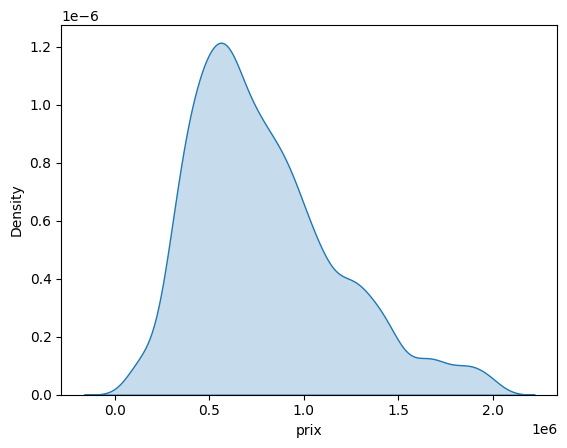

In [ ]:
# densité de la variable prix sous forme de distribution

sns.kdeplot(data = dataset, x = 'prix', fill=True)

<Axes: xlabel='surface', ylabel='Count'>

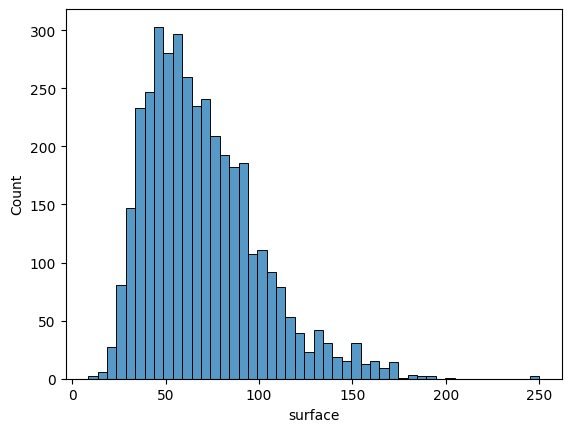

In [ ]:
# Visualiser la surface en histogramme

sns.histplot(dataset['surface'])

<Axes: xlabel='si_balcon', ylabel='count'>

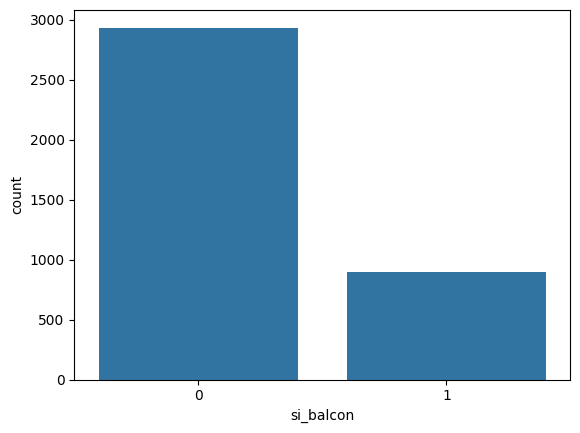

In [ ]:
# Visualiser la variable si_balcon en countplot

sns.countplot(data=dataset, x='si_balcon')


<Axes: xlabel='surface', ylabel='prix'>

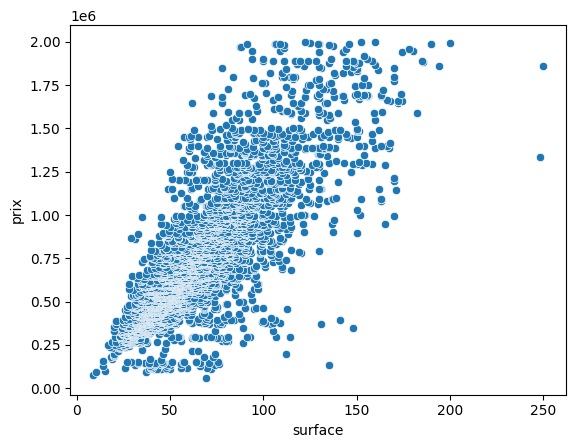

In [ ]:
# Visualiser le prix en fonction de la surface

sns.scatterplot(data=dataset, x='surface', y='prix')

<Axes: xlabel='prix', ylabel='Density'>

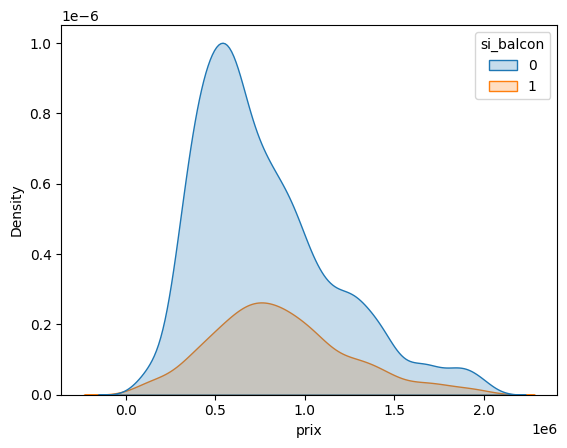

In [ ]:
# densité de la variable prix en fonction de si_balcon sous forme de disribution

sns.kdeplot(data = dataset, x = 'prix', hue='si_balcon', fill=True)

<Axes: xlabel='si_balcon', ylabel='prix'>

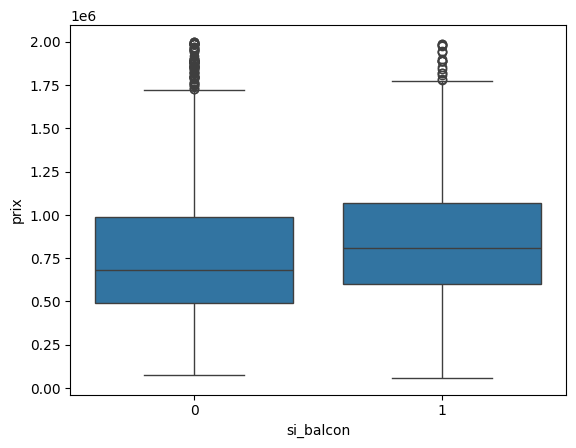

In [ ]:
# Visualiser le prix en fonction de si_balcon en boxplot

sns.boxplot(data=dataset, x='si_balcon', y='prix')

Regardons maintenant les distributions des différentes variables numériques.

Nous allons étudier maintenant les corrélation entre les variables numériques et la variable d'intérêt `prix`.

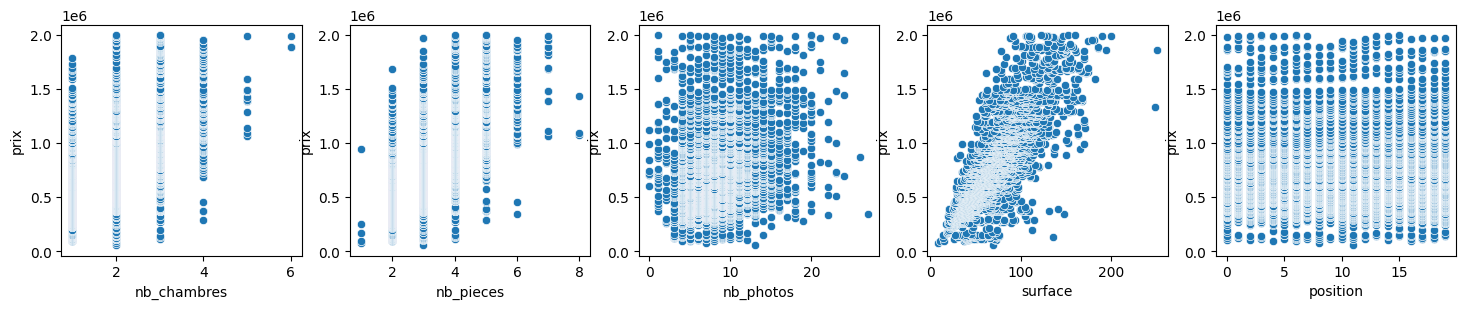

In [ ]:
fig, axs = plt.subplots(1,5, figsize=(18,3))
for i, feature in enumerate(numerical):
    sns.scatterplot(x = dataset[feature], y = dataset['prix'], ax = axs[i])
plt.show()

Le nombre de chambres est bien une variable numérique. Mais c'est une variable discrète qui prend un nombre relativement faible de valeurs. Il est préférable de la traiter ici comme une variable catégirielle (ou plutôt ordinale).

In [ ]:
for indice, feature in enumerate(numerical):
   print(indice, feature)

0 nb_chambres
1 nb_pieces
2 nb_photos
3 surface
4 position


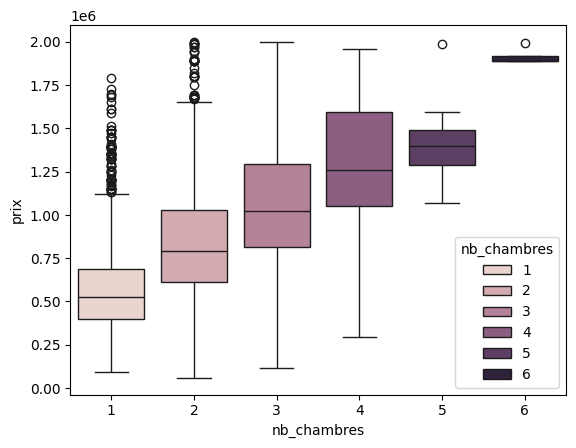

In [ ]:
# Le prix en fonction du nombre de chambres sous forme de boxplot

sns.boxplot(data=dataset, x='nb_chambres', y='prix', hue = 'nb_chambres')
plt.show()

Nous allons faire la même chose pour la variable position

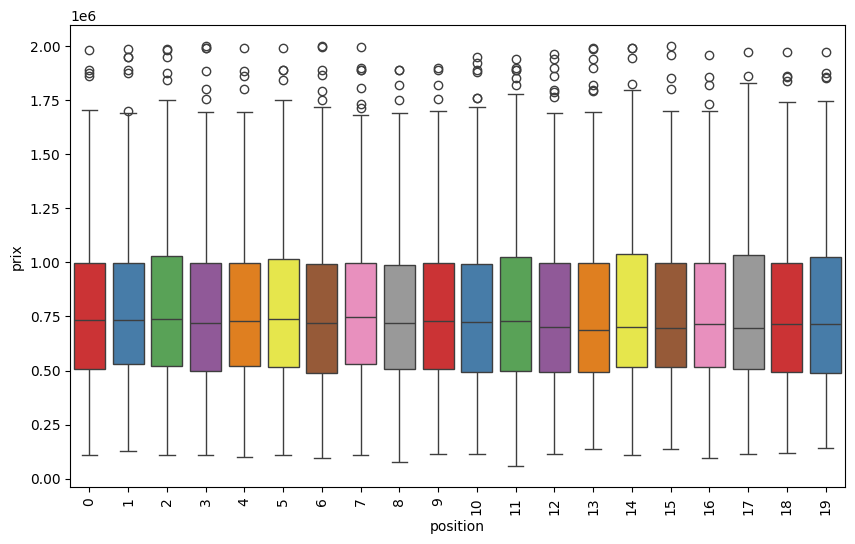

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(y=dataset['prix'], x=dataset['position'], hue=dataset['position'], ax=ax, palette='Set1', legend=False)
ax.tick_params(axis='x', rotation=90)
plt.show()

<Axes: >

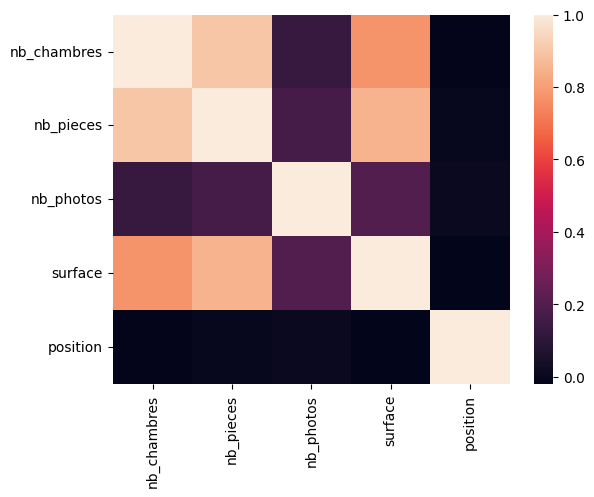

In [ ]:
# Tracer un corrélogramme des variables numériques
sns.heatmap(dataset[numerical].corr())

### Variables catégorielles

On peut commencer pas visualiser les variables qui ont un faible nombre de modalités en fonction de la variable `prix`.

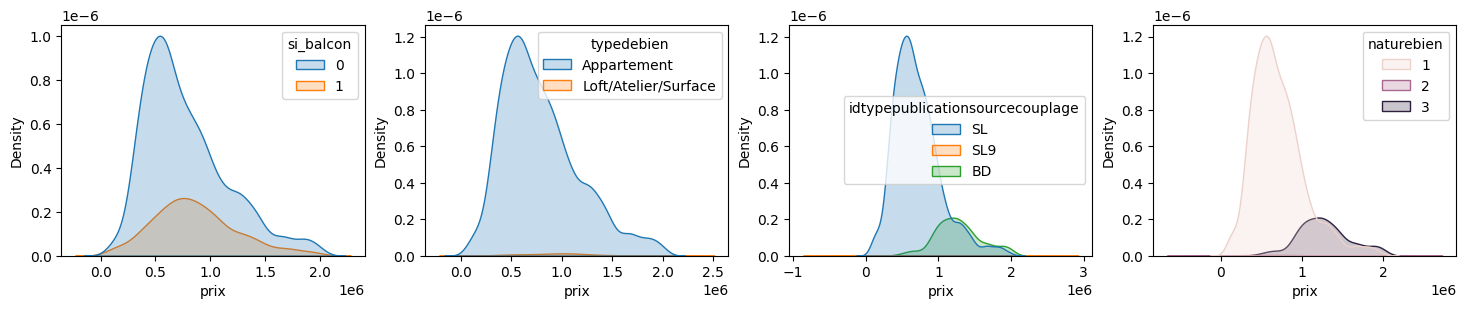

In [ ]:
categorical_sub = ['si_balcon', 'typedebien', 'idtypepublicationsourcecouplage', 'naturebien']
fig, axs = plt.subplots(1, 4, figsize=(18,3))
for i, feature in enumerate(categorical_sub):
    sns.kdeplot(data = dataset, x="prix", hue = feature, fill=True, ax = axs[i])

plt.show()

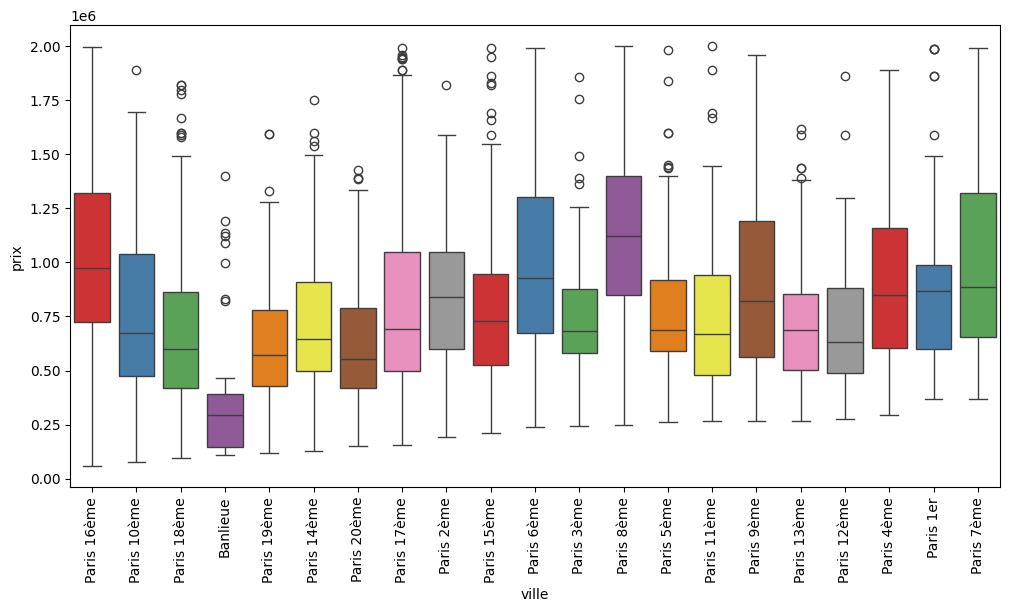

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(y=dataset['prix'], x=dataset['ville'], hue=dataset['ville'], ax=ax, palette='Set1', legend=False)
ax.tick_params(axis='x', rotation=90)
plt.show()

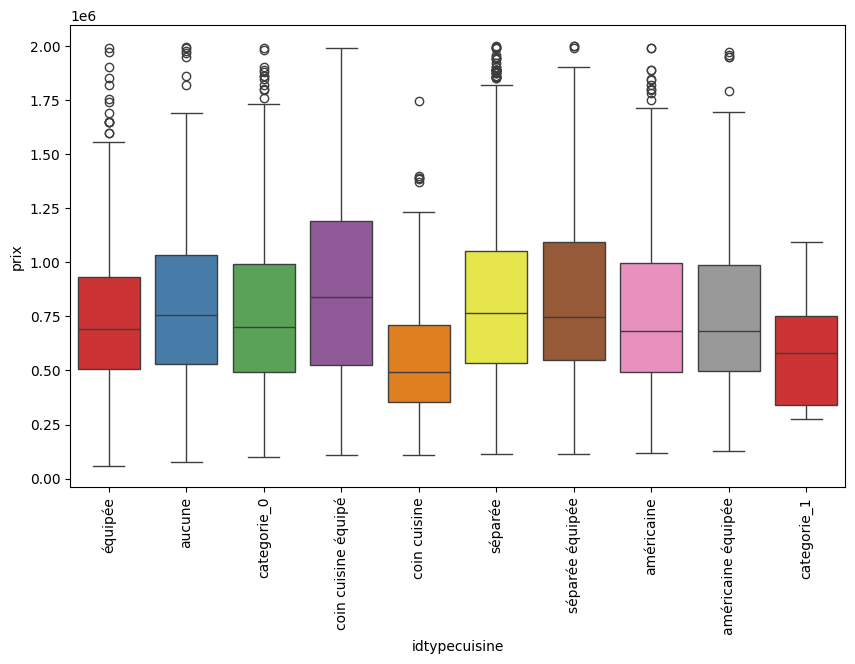

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(y=dataset['prix'], x=dataset['idtypecuisine'], hue=dataset['idtypecuisine'], ax=ax, palette='Set1', legend=False)
ax.tick_params(axis='x', rotation=90)
plt.show()

In [ ]:
dataset.head()

,idtypecuisine,idtypepublicationsourcecouplage,naturebien,nb_chambres,nb_photos,nb_pieces,position,prix,si_balcon,surface,typedebien,ville
0,équipée,SL,1,2,13,3,11,59000,1,69.00,Appartement,Paris 16ème
1,aucune,SL,1,2,7,1,8,77500,0,8.49,Appartement,Paris 10ème
2,aucune,SL,1,1,8,2,6,94000,0,37.00,Appartement,Paris 18ème
3,aucune,SL,1,2,4,1,16,96000,0,10.26,Appartement,Paris 10ème
4,categorie_0,SL,1,1,5,2,4,100000,0,14.93,Appartement,Paris 16ème


# Approche explicative : étude des déterminants du prix

On va maintenant essayer de comprendre quelles sont les variables les plus déterminantes qui exliquent le prix d'un bien immobilier. Pour ce faire, nous allons utiliser un modèle de régression linéaire. Mais il nous reste encore une étape : transformer les variables catégorielles en variables numériques.

In [ ]:
dataset.columns

Index(['idtypecuisine', 'idtypepublicationsourcecouplage', 'naturebien',
       'nb_chambres', 'nb_photos', 'nb_pieces', 'position', 'prix',
       'si_balcon', 'surface', 'typedebien', 'ville'],
      dtype='object')

In [ ]:
# Transformer les variables catégorielles en variables numériques avec du one-hot encoding il ne reste que des variables numérique
categorical_sub = [
     'typedebien', 'idtypepublicationsourcecouplage',
    'naturebien','idtypecuisine', 'ville'
]


df = pd.get_dummies(dataset, columns = categorical_sub, drop_first=True).astype(int)
df.head()

,nb_chambres,nb_photos,nb_pieces,position,prix,si_balcon,surface,typedebien_Loft/Atelier/Surface,idtypepublicationsourcecouplage_SL,idtypepublicationsourcecouplage_SL9,naturebien_2,naturebien_3,...,ville_Paris 18ème,ville_Paris 19ème,ville_Paris 1er,ville_Paris 20ème,ville_Paris 2ème,ville_Paris 3ème,ville_Paris 4ème,ville_Paris 5ème,ville_Paris 6ème,ville_Paris 7ème,ville_Paris 8ème,ville_Paris 9ème
0,2,13,3,11,59000,1,69,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0
1,2,7,1,8,77500,0,8,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0
2,1,8,2,6,94000,0,37,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0
3,2,4,1,16,96000,0,10,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0
4,1,5,2,4,100000,0,14,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(3833, 41)

$$ \beta = (XX^T)^{-1}X^Ty$$

## Régression linéaire

In [ ]:
import statsmodels.api as sm

# Définir la variable dépendante (label) y et les variables explicatives X
y = df['prix']
X = df.drop(['prix'], axis=1)

# Ajouter une constante à la matrice de design X
X = sm.add_constant(X)

# Ajuster un modèle linéaire
model = sm.OLS(y, X).fit()

# Afficher les informations sur le modèle
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   prix   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     430.0
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:30:11   Log-Likelihood:                -51461.
No. Observations:                3833   AIC:                         1.030e+05
Df Residuals:                    3792   BIC:                         1.033e+05
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

# Prédire les prix

On se propose maintenant de prédire les prix des biens immobliers.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import numpy as np
# Séparer les données en données d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraîner le modèle de régression linéaire sur les données d'entraînement
model = sm.OLS(y_train, X_train).fit()

# Prédire les prix des biens immobiliers sur les données de test
y_pred = model.predict(X_test)

# Évaluer les performances du modèle
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean squared error: {rmse:.2f}")


Root Mean squared error: 170974.57


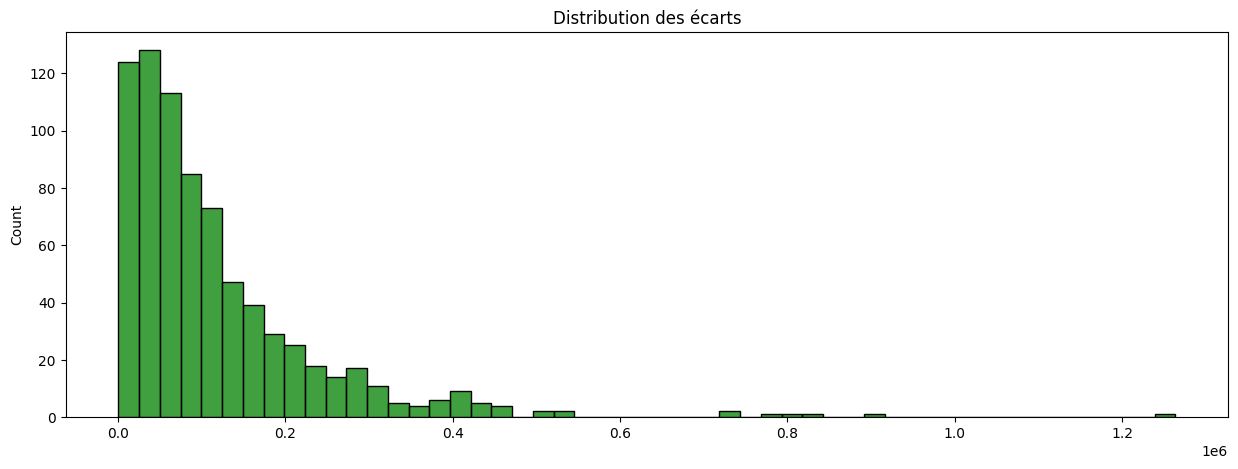

In [ ]:


ecarts = np.abs(y_pred - y_test)

fig, ax = plt.subplots(figsize=(15, 5))
sns.histplot(ecarts, ax=ax, color='green', kde=False)
ax.set_title('Distribution des écarts')
plt.show()


In [ ]:
# Define selected_columns based on the columns used to train the model
# In this case, it's all columns of X_train
selected_columns = X_train.columns

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

# Define the prediction function
def predict_price(
    surface,
    si_balcon,
    property_type,
    kitchen_type,
    city
):
    # Create a DataFrame for the new input, initialized with zeros, using X_train's columns
    # This ensures all necessary one-hot encoded columns are present and in the correct order
    input_data = pd.DataFrame(0, index=[0], columns=selected_columns)

    # Add the constant term if it's part of the model's selected_columns
    if 'const' in input_data.columns:
        input_data['const'] = 1.0

    # Set numerical features
    input_data['surface'] = surface

    # Set binary categorical features
    input_data['si_balcon'] = 1 if si_balcon else 0

    # Set one-hot encoded 'typedebien'
    # The base category 'Appartement' corresponds to all 'typedebien' columns being 0
    if property_type == 'Loft/Atelier/Surface' and 'typedebien_Loft/Atelier/Surface' in input_data.columns:
        input_data['typedebien_Loft/Atelier/Surface'] = 1

    # Set one-hot encoded 'idtypecuisine'
    # The base category 'aucune' corresponds to all 'idtypecuisine' columns being 0
    if kitchen_type == 'séparée' and 'idtypecuisine_séparée' in input_data.columns:
        input_data['idtypecuisine_séparée'] = 1
    elif kitchen_type == 'équipée' and 'idtypecuisine_équipée' in input_data.columns:
        input_data['idtypecuisine_équipée'] = 1
    elif kitchen_type == 'coin cuisine équipé' and 'idtypecuisine_coin cuisine équipé' in input_data.columns:
        input_data['idtypecuisine_coin cuisine équipé'] = 1
    elif kitchen_type == 'coin cuisine' and 'idtypecuisine_coin cuisine' in input_data.columns:
        input_data['idtypecuisine_coin cuisine'] = 1
    elif kitchen_type == 'américaine' and 'idtypecuisine_américaine' in input_data.columns:
        input_data['idtypecuisine_américaine'] = 1
    elif kitchen_type == 'américaine équipée' and 'idtypecuisine_américaine équipée' in input_data.columns:
        input_data['idtypecuisine_américaine équipée'] = 1
    elif kitchen_type == 'séparée équipée' and 'idtypecuisine_séparée équipée' in input_data.columns:
        input_data['idtypecuisine_séparée équipée'] = 1
    elif kitchen_type == 'categorie_0' and 'idtypecuisine_categorie_0' in input_data.columns:
        input_data['idtypecuisine_categorie_0'] = 1
    elif kitchen_type == 'categorie_1' and 'idtypecuisine_categorie_1' in input_data.columns:
        input_data['idtypecuisine_categorie_1'] = 1

    # Set one-hot encoded 'ville' features
    # The base category 'Banlieue' corresponds to all 'ville' columns being 0
    if city != 'Banlieue' and f'ville_{city}' in input_data.columns:
        input_data[f'ville_{city}'] = 1

    # Ensure the order of columns matches the model's training data
    input_data = input_data[selected_columns]

    # Make prediction
    predicted_price = model.predict(input_data)[0]

    return f"{predicted_price:,.2f} €"

# Get unique values for dropdowns from the original dataset for user-friendly labels
property_types_options = dataset['typedebien'].unique().tolist()
kitchen_types_options = dataset['idtypecuisine'].unique().tolist()
city_options = dataset['ville'].unique().tolist()


# Create Gradio interface
interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Slider(minimum=1, maximum=250, step=1, value=50, label="Surface (m²)"),
        gr.Checkbox(label="Avec Balcon"),
        gr.Dropdown(property_types_options, label="Type de bien", value='Appartement'),
        gr.Dropdown(kitchen_types_options, label="Type de cuisine", value='aucune'),
        gr.Dropdown(city_options, label="Ville", value='Paris 16ème')
    ],
    outputs=gr.Textbox(label="Prix Prédit"),
    title="Prédiction du Prix des Biens Immobiliers",
    description="Entrez les caractéristiques du bien pour obtenir une estimation de son prix.",
    theme=gr.themes.Soft()
)

# Launch the interface
interface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1ab27c038ba52a7820.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
